In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns

In [26]:
df_25 = pd.read_csv('/Users/arjunbaronia/Downloads/analytic_data2025_v3.csv', low_memory = False, skiprows = 1)

In [27]:
df_25.shape

(3204, 796)

In [28]:
relevant_columns = {
    'fipscode':'fipscode',
    'state': 'state',
    'county': 'county',
    'v147_rawvalue': 'life_expectancy',
    'v063_rawvalue': 'median_household_income',
    'v044_rawvalue': 'income_inequality',
    'v024_rawvalue': 'child_poverty',
    'v023_rawvalue': 'unemployment',
    'v009_rawvalue': 'smoking',
    'v011_rawvalue': 'obesity',
    'v070_rawvalue': 'physical_inactivity',
    'v049_rawvalue': 'excessive_drinking',
    'v143_rawvalue': 'insufficient_sleep',
    'v085_rawvalue': 'uninsured',
    'v004_rawvalue': 'primary_care_physicians',
    'v005_rawvalue': 'preventable_hospital_stays',
    'v062_rawvalue': 'mental_health_providers',
    'v069_rawvalue': 'some_college',
    'v139_rawvalue': 'food_insecurity',
    'v125_rawvalue': 'air_pollution',
    'v136_rawvalue': 'severe_housing_problems',
    'v132_rawvalue': 'exercise_access',
    'v058_rawvalue': 'percent_rural',
    'v053_rawvalue': 'percent_senior',
    'v054_rawvalue': 'percent_black',
    'v056_rawvalue': 'percent_hispanic',
    'v060_rawvalue': 'diabetes_prevalence',
    'v138_rawvalue': 'drug_overdose_deaths',
    'v183_rawvalue': 'loneliness',
    'v083_rawvalue': 'limited_access_healthy_foods',
    'v179_rawvalue': 'access_to_parks',
    'v184_rawvalue': 'lack_social_emotional_support',
    'v155_rawvalue': 'flu_vaccinations',
    'v004_other_data_1': 'ratio_pop_to_pcp',
    'v062_other_data_1': 'ratio_pop_to_mental_health_providers',
    'v124_rawvalue': 'drinking_water_violations'
}

In [29]:
df = df_25[list(relevant_columns.keys())].rename(columns=relevant_columns)

In [62]:
df[["life_expectancy", "county", "state"]].sort_values(by="life_expectancy")

,life_expectancy,county,state
2422,53.980813,Buffalo County,SD
2434,56.655044,Dewey County,SD
2465,56.934652,Oglala Lakota County,SD
2429,58.713837,Corson County,SD
2474,58.745425,Todd County,SD
...,...,...,...
271,89.667160,Eagle County,CO
2068,92.203267,Oliver County,ND
311,92.415882,Summit County,CO
218,93.553610,Mono County,CA


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 36 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   fipscode                              3204 non-null   int64  
 1   state                                 3204 non-null   object 
 2   county                                3204 non-null   object 
 3   life_expectancy                       3120 non-null   float64
 4   median_household_income               3195 non-null   float64
 5   income_inequality                     3174 non-null   float64
 6   child_poverty                         3195 non-null   float64
 7   unemployment                          3194 non-null   float64
 8   smoking                               3196 non-null   float64
 9   obesity                               3196 non-null   float64
 10  physical_inactivity                   3196 non-null   float64
 11  excessive_drinkin

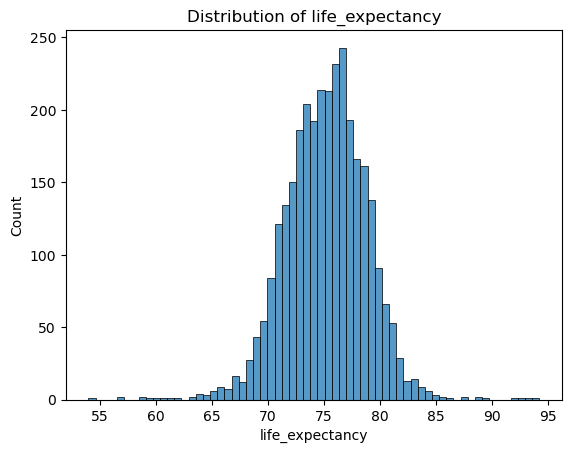

In [31]:
sns.histplot(data=df, x='life_expectancy')
plt.title('Distribution of life_expectancy')
plt.xlabel('life_expectancy')
plt.show()

In [32]:
print('median    ', df['life_expectancy'].median())
print(df['life_expectancy'].describe())

median     75.309788385
count    3120.000000
mean       75.171058
std         3.612053
min        53.980813
25%        72.822953
50%        75.309788
75%        77.559467
max        94.218993
Name: life_expectancy, dtype: float64


In [33]:
states = pd.read_csv('/Users/arjunbaronia/Downloads/states.csv')
states.rename(columns={'State Code': 'state'}, inplace=True)

In [34]:
df = pd.merge(df, states[['state', 'Region']], on='state', how ='left')

In [35]:
df = df.drop(0)
df.head()

,fipscode,state,county,life_expectancy,median_household_income,income_inequality,child_poverty,unemployment,smoking,obesity,...,drug_overdose_deaths,loneliness,limited_access_healthy_foods,access_to_parks,lack_social_emotional_support,flu_vaccinations,ratio_pop_to_pcp,ratio_pop_to_mental_health_providers,drinking_water_violations,Region
1,1000,AL,Alabama,73.279289,62248.0,5.167305,0.213,0.024982,0.162,0.384,...,26.131133,0.334,0.087605,0.167805,0.271,0.41,1571.033978,683.864525,0.149254,South
2,1001,AL,Autauga County,74.800646,68857.0,4.273712,0.170,0.021889,0.154,0.384,...,10.857205,0.343,0.130210,0.053958,0.240,0.36,2272.884615,2742.818182,0.000000,South
3,1003,AL,Baldwin County,76.580109,74248.0,4.359526,0.141,0.022795,0.147,0.368,...,31.607684,0.316,0.079368,0.165722,0.225,0.44,1595.293333,828.454248,0.000000,South
4,1005,AL,Barbour County,72.708992,45298.0,5.614339,0.348,0.044310,0.219,0.438,...,16.159657,0.357,0.104332,0.097332,0.307,0.39,2496.400000,3512.142857,0.000000,South
5,1007,AL,Bibb County,72.977379,56025.0,5.346727,0.214,0.024624,0.218,0.414,...,27.019724,0.363,0.004459,0.182120,0.290,0.31,1498.466667,2733.500000,1.000000,South


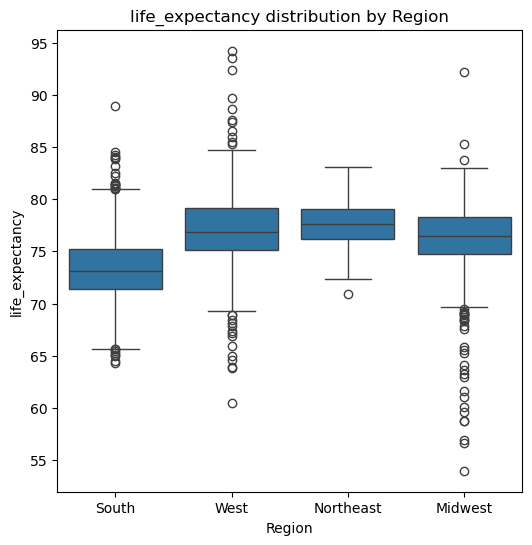

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.boxplot(data=df, y='life_expectancy', x='Region')
plt.title('life_expectancy distribution by Region')
plt.show()

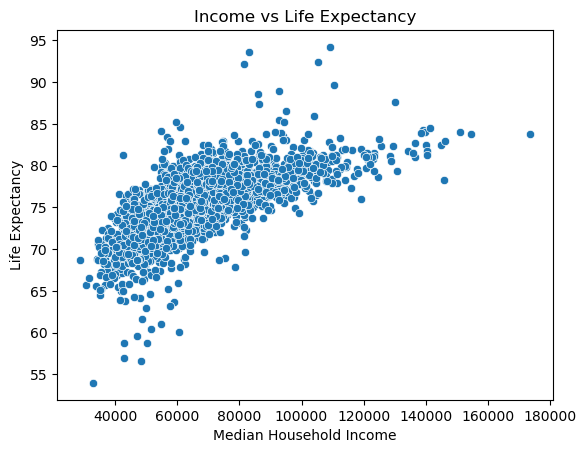

In [13]:
sns.scatterplot(data=df, x='median_household_income', y='life_expectancy')
plt.title('Income vs Life Expectancy')
plt.xlabel('Median Household Income')
plt.ylabel('Life Expectancy')
plt.show()

In [37]:
# introducing bins for income group and county population density
df['income_group'] = pd.qcut(df['median_household_income'], q=3, labels=['low', 'middle', 'high'])
df['pop_density'] = pd.cut(df['percent_rural'], bins=[0, .33, .66, 1.0], labels=['urban', 'suburban', 'rural'])

In [38]:
#feature creation 
df['behavioral_risk_score'] = (df['smoking']+df['obesity']+df['physical_inactivity']+df['excessive_drinking']+df['insufficient_sleep'])/5
df["healthcare_access_score"] = (df['preventable_hospital_stays'] + df['ratio_pop_to_pcp'] + df['uninsured'])/3

In [39]:
# Addressed nulls 
num = list(df.select_dtypes(include=['number']).columns)
num.remove("fipscode")

df = df.dropna(subset=['life_expectancy'])
df[num] = df[num].fillna(df.groupby('state')[num].transform('median'))
df[num] = df[num].fillna(df[num].median())

In [17]:
correlations = df[num].corrwith(df['life_expectancy'])
correlations.sort_values(ascending=False)

life_expectancy                         1.000000
median_household_income                 0.700448
some_college                            0.601015
excessive_drinking                      0.582950
exercise_access                         0.374706
flu_vaccinations                        0.350486
primary_care_physicians                 0.287571
access_to_parks                         0.275424
mental_health_providers                 0.122935
percent_senior                          0.107795
percent_hispanic                        0.083418
drinking_water_violations               0.055383
air_pollution                          -0.018360
severe_housing_problems                -0.080861
ratio_pop_to_mental_health_providers   -0.136053
limited_access_healthy_foods           -0.198072
ratio_pop_to_pcp                       -0.212828
percent_rural                          -0.252531
uninsured                              -0.311445
unemployment                           -0.324541
loneliness          

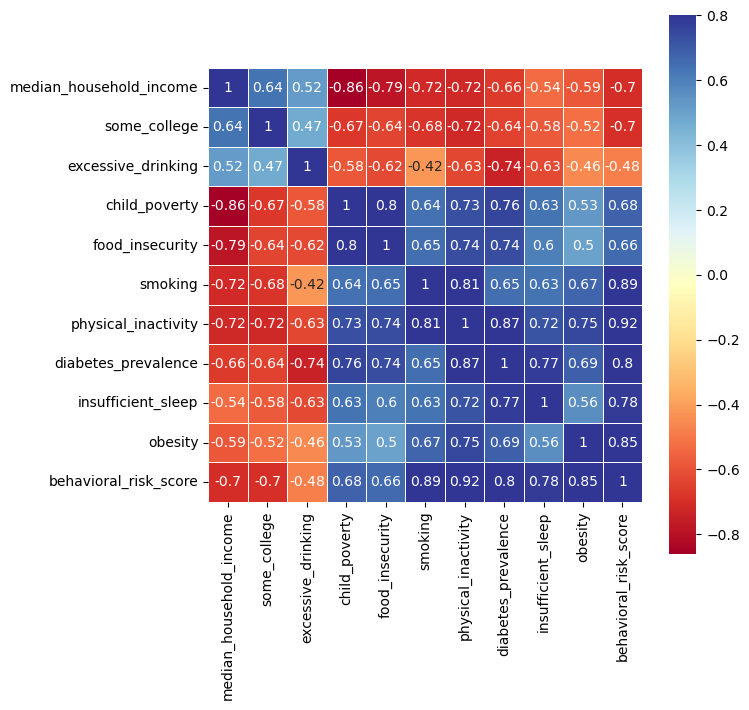

In [18]:
high_corr_features = ['median_household_income', 'some_college', 'excessive_drinking', 'child_poverty', 
                     'food_insecurity', 'smoking', 'physical_inactivity', 'diabetes_prevalence', 
                     'insufficient_sleep', 'obesity', 'behavioral_risk_score']

corrmat = df[high_corr_features].corr(method = 'spearman')
corrmat
f, ax = plt.subplots(figsize = (7,7))
sns.heatmap(corrmat, vmax = .8, square = True, annot = True, cmap = 'RdYlBu', linewidths = .5 )
plt.show()

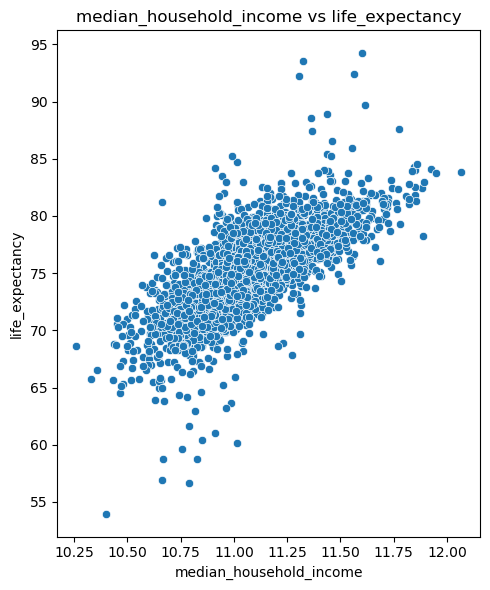

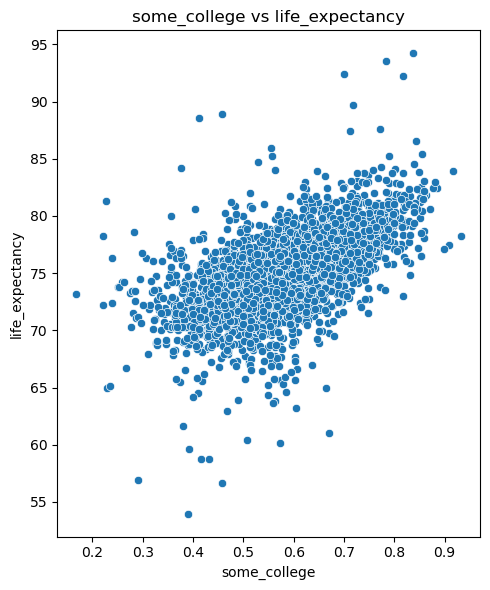

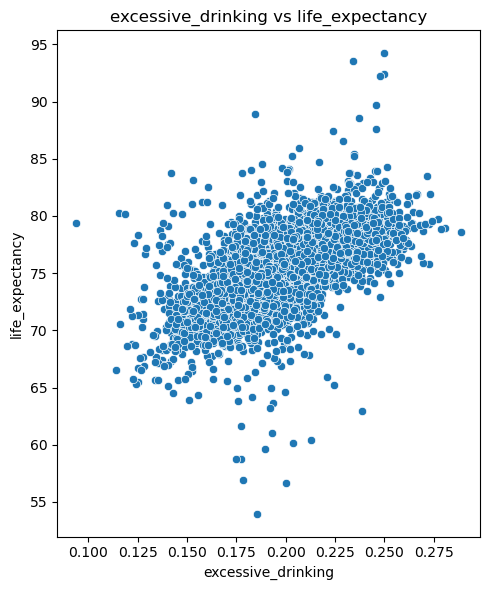

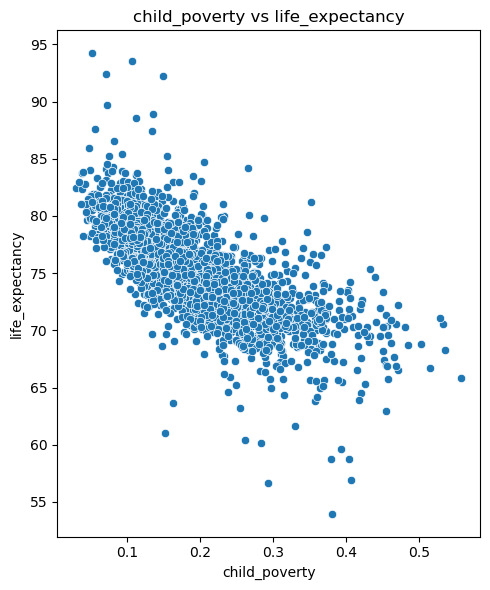

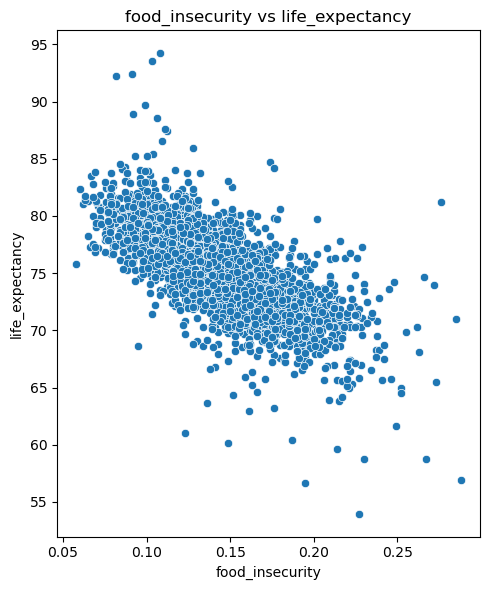

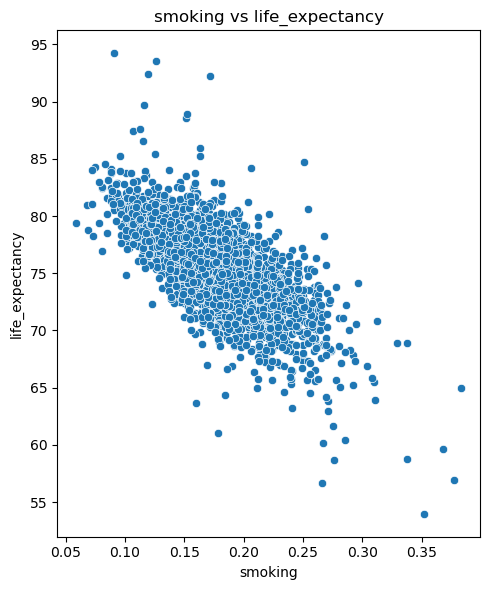

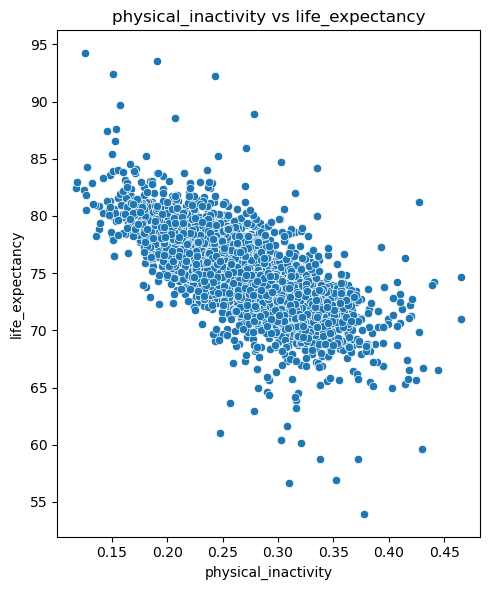

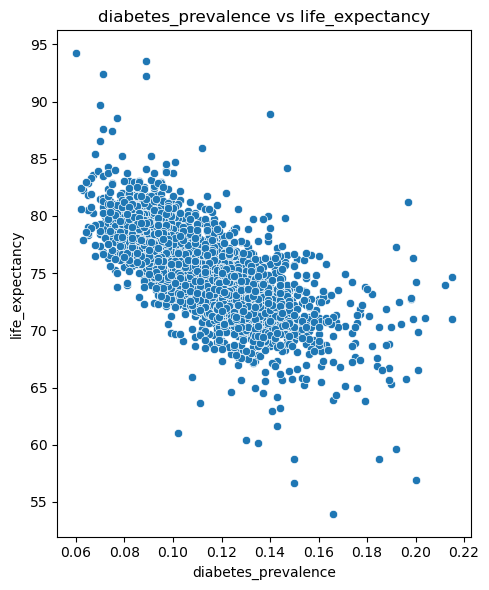

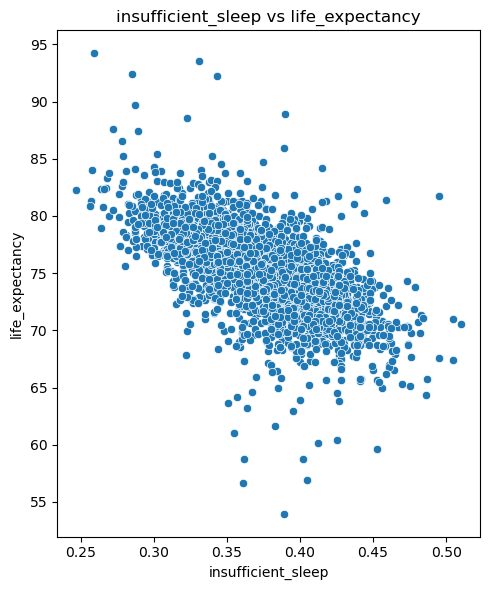

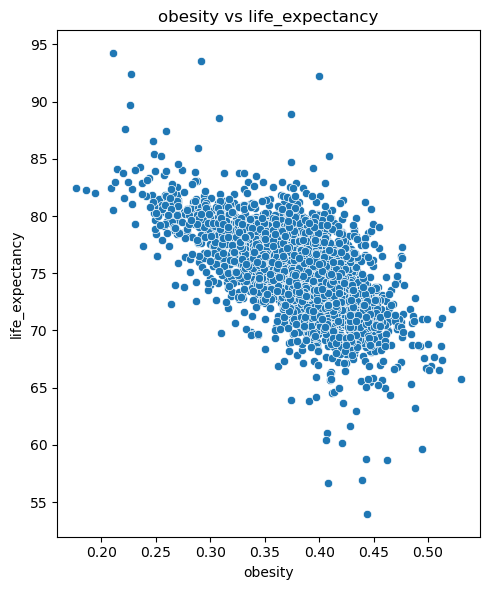

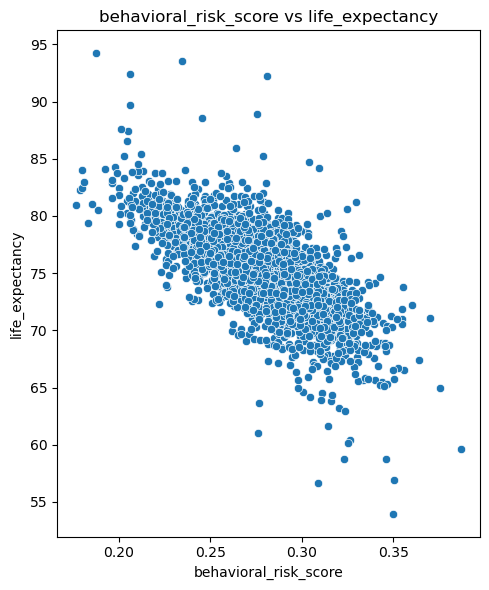

In [42]:
for col in high_corr_features:
    plt.figure(figsize=(5, 6))
    sns.scatterplot(data=df, x=col, y='life_expectancy')
    plt.title(f'{col} vs life_expectancy')
    plt.tight_layout()
    plt.show()

In [41]:
# Fixed skew 
skew = df[num].skew()
skew_to_fix = list(skew[skew >1].index)
df[skew_to_fix] = np.log1p(df[skew_to_fix])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3119 entries, 1 to 3203
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   fipscode                              3119 non-null   int64   
 1   state                                 3119 non-null   object  
 2   county                                3119 non-null   object  
 3   life_expectancy                       3119 non-null   float64 
 4   median_household_income               3119 non-null   float64 
 5   income_inequality                     3119 non-null   float64 
 6   child_poverty                         3119 non-null   float64 
 7   unemployment                          3119 non-null   float64 
 8   smoking                               3119 non-null   float64 
 9   obesity                               3119 non-null   float64 
 10  physical_inactivity                   3119 non-null   float64 
 11  excessive

In [22]:
# Split data in X and y
y = df['life_expectancy']
X = df.drop(columns=['life_expectancy', 'fipscode', 'county', 'state', 'Region'])

In [50]:
from sklearn.linear_model import LinearRegression

median_household_income_X = df[['median_household_income']]
life_expectancy_y = df['life_expectancy']

lin_reg = LinearRegression()
lin_reg.fit(median_household_income_X, life_expectancy_y)

df['life_expectancy_residual'] = life_expectancy_y - lin_reg.predict(median_household_income_X)

In [59]:
df[["county", "state", "life_expectancy_residual", "percent_rural"]].sort_values(by="life_expectancy_residual")

,county,state,life_expectancy_residual,percent_rural
2434,Dewey County,SD,-15.422221,1.000000
2038,Benson County,ND,-14.450883,1.000000
2465,Oglala Lakota County,SD,-13.748234,1.000000
2474,Todd County,SD,-13.737310,1.000000
2422,Buffalo County,SD,-13.731329,1.000000
...,...,...,...,...
2052,Golden Valley County,ND,10.899624,1.000000
311,Summit County,CO,11.686322,0.161005
301,Pitkin County,CO,13.058487,0.329646
2068,Oliver County,ND,14.335901,1.000000


In [43]:
cat_attribs = ["income_group", "pop_density"]
num_attribs = list(X.select_dtypes(include=['number']).columns)

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


num_pipeline = Pipeline([
        ('std_scaler', StandardScaler()),
    ])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])